# **Sentiment Classification Using BERT Family Models**

## Objective

* The objective of this notebook is to build BERT family models that predicts whether a movie review is **negative** or **positive**.


## Dataset

* This notebook uses the **IMDb labelled review dataset** [Link to access](https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences)
* Each review is assigned a sentiment label:

  * `0` = Negative sentiment
  * `1` = Positive sentiment
* In this notebook, each review is treated as one document, and the goal is to classify the sentiment of the whole review.


In [1]:
# setting logging to print only error messages of sklearnex
import logging
logging.basicConfig()
logging.getLogger("SKLEARNEX").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import nltk

from bs4 import BeautifulSoup
from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

In [2]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# **Data import**

In [3]:
from google.colab import files
uploaded = files.upload()

Saving imdb_labelled.txt to imdb_labelled (1).txt


In [4]:
df = pd.read_csv(
    "imdb_labelled.txt",
    sep="\t",
    header=None,
    names=["text", "label"]
)

In [5]:
.head()

,text,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    748 non-null    object
 1   label   748 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.8+ KB


# **Data Preprocessing**

In [7]:
import re

def clean_for_bert(text):
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "", text)  # remove URLs
    text = re.sub(r"\s+", " ", text).strip()    # remove extra spaces
    return text

df["bert_text"] = df["text"].fillna("").apply(clean_for_bert)

In [8]:
df.head()

,text,label,bert_text
0,"A very, very, very slow-moving, aimless movie ...",0,"A very, very, very slow-moving, aimless movie ..."
1,Not sure who was more lost - the flat characte...,0,Not sure who was more lost - the flat characte...
2,Attempting artiness with black & white and cle...,0,Attempting artiness with black & white and cle...
3,Very little music or anything to speak of.,0,Very little music or anything to speak of.
4,The best scene in the movie was when Gerardo i...,1,The best scene in the movie was when Gerardo i...


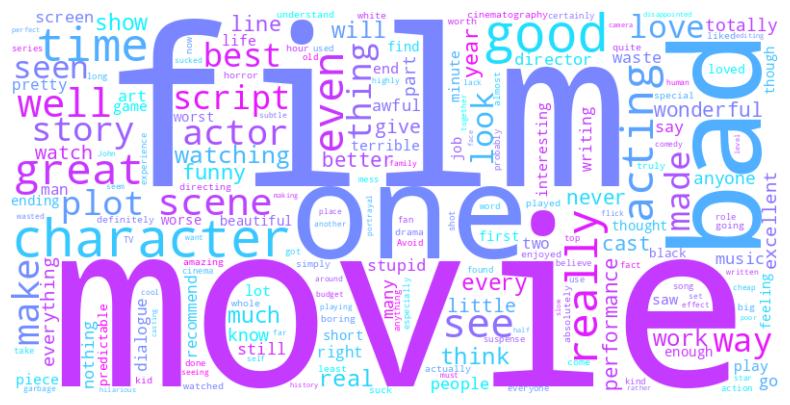

In [13]:
from wordcloud import WordCloud
# Generate the word cloud from the processed content
text = " ".join(review for review in df['bert_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='cool').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
#plt.title('Word Cloud of Processed Content')
plt.show()

* Words such as movie, film, character, acting, and story are highly frequent, which is expected because the dataset contains movie reviews.

* Some sentiment-related words, such as good, bad, great, excellent, and awful, also appear, suggesting that the text contains useful signals for sentiment classification.



# **Model Development**

In [14]:
!pip install transformers

In [15]:
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# **DistilBERT**

In [16]:
# Load pretrained sentiment model
db_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [17]:
# Predict sentiment for each document
df["db_result"] = df["bert_text"].astype(str).apply(lambda x: db_model(x[:512])[0]["label"])

In [18]:
df.head()

,text,label,bert_text,db_result
0,"A very, very, very slow-moving, aimless movie ...",0,"A very, very, very slow-moving, aimless movie ...",NEGATIVE
1,Not sure who was more lost - the flat characte...,0,Not sure who was more lost - the flat characte...,NEGATIVE
2,Attempting artiness with black & white and cle...,0,Attempting artiness with black & white and cle...,NEGATIVE
3,Very little music or anything to speak of.,0,Very little music or anything to speak of.,NEGATIVE
4,The best scene in the movie was when Gerardo i...,1,The best scene in the movie was when Gerardo i...,POSITIVE


In [19]:
df["db_label"] = df["db_result"].map({
    "NEGATIVE": 0,
    "POSITIVE": 1
})

In [20]:
df.head()

,text,label,bert_text,db_result,db_label
0,"A very, very, very slow-moving, aimless movie ...",0,"A very, very, very slow-moving, aimless movie ...",NEGATIVE,0
1,Not sure who was more lost - the flat characte...,0,Not sure who was more lost - the flat characte...,NEGATIVE,0
2,Attempting artiness with black & white and cle...,0,Attempting artiness with black & white and cle...,NEGATIVE,0
3,Very little music or anything to speak of.,0,Very little music or anything to speak of.,NEGATIVE,0
4,The best scene in the movie was when Gerardo i...,1,The best scene in the movie was when Gerardo i...,POSITIVE,1


In [21]:
y_true = df["label"]
y_pred_db = df["db_label"]

print("Accuracy:", accuracy_score(y_true, y_pred_db))
print(classification_report(y_true, y_pred_db))
print(confusion_matrix(y_true, y_pred_db))

Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       362
           1       0.96      0.93      0.94       386

    accuracy                           0.94       748
   macro avg       0.94      0.94      0.94       748
weighted avg       0.94      0.94      0.94       748

[[346  16]
 [ 28 358]]


# **BERT**

In [22]:
# Install if needed
!pip install transformers torch -q

In [23]:
from transformers import pipeline

# Load original BERT model fine-tuned for sentiment classification
bert_model = pipeline(
    "sentiment-analysis",
    model="textattack/bert-base-uncased-SST-2",
    tokenizer="textattack/bert-base-uncased-SST-2"
)

config.json:   0%|          | 0.00/477 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [24]:
# Predict sentiment for each review
df["bert_result"] = df["bert_text"].astype(str).apply(
    lambda x: bert_model(
        x,
        truncation=True,
        max_length=512
    )[0]["label"]
)

In [25]:
df.head()

,text,label,bert_text,db_result,db_label,bert_result
0,"A very, very, very slow-moving, aimless movie ...",0,"A very, very, very slow-moving, aimless movie ...",NEGATIVE,0,LABEL_0
1,Not sure who was more lost - the flat characte...,0,Not sure who was more lost - the flat characte...,NEGATIVE,0,LABEL_0
2,Attempting artiness with black & white and cle...,0,Attempting artiness with black & white and cle...,NEGATIVE,0,LABEL_0
3,Very little music or anything to speak of.,0,Very little music or anything to speak of.,NEGATIVE,0,LABEL_0
4,The best scene in the movie was when Gerardo i...,1,The best scene in the movie was when Gerardo i...,POSITIVE,1,LABEL_1


In [27]:
# Convert text labels into numbers
df["bert_label"] = df["bert_result"].map({
    "LABEL_0": 0,
    "LABEL_1": 1
})

In [29]:
df.drop(columns=["bert_result","db_result"], inplace=True)

In [30]:
df.head()

,text,label,bert_text,db_label,bert_label
0,"A very, very, very slow-moving, aimless movie ...",0,"A very, very, very slow-moving, aimless movie ...",0,0
1,Not sure who was more lost - the flat characte...,0,Not sure who was more lost - the flat characte...,0,0
2,Attempting artiness with black & white and cle...,0,Attempting artiness with black & white and cle...,0,0
3,Very little music or anything to speak of.,0,Very little music or anything to speak of.,0,0
4,The best scene in the movie was when Gerardo i...,1,The best scene in the movie was when Gerardo i...,1,1


In [31]:
y_true = df["label"]
y_pred_bert = df["bert_label"]

print("Accuracy:", accuracy_score(y_true, y_pred_bert))
print(classification_report(y_true, y_pred_bert))
print(confusion_matrix(y_true, y_pred_bert))

Accuracy: 0.9598930481283422
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       362
           1       0.96      0.96      0.96       386

    accuracy                           0.96       748
   macro avg       0.96      0.96      0.96       748
weighted avg       0.96      0.96      0.96       748

[[348  14]
 [ 16 370]]


# **Citing this Notebook**

If you use this notebook in your work, please cite it as follows:

Linh, H. (2026). Machine Learning for Business. Lecture examples and exercises. (Version 1.0.0). URL: https://github.com/MsLinhEIU/MIS-451---Machine-Learning-for-Business-Analytics/tree/main